In [ ]:
#Chocolate factory data 

In [30]:
import numpy as np
import pandas as pd

data = pd.read_excel("C:/Users/hp5cd/OneDrive/Desktop/chocolate_sales.xlsx")

df = pd.DataFrame(data)
print(df)

          Date  Product   Location  Units_Sold  Price  Revenue
0   2024-01-01     Dark    Ballari         120     50     6000
1   2024-01-02     Milk  Bengaluru         150     40     6000
2   2024-01-03    White     Mysuru         100     45     4500
3   2024-01-04  Truffle   Hubballi          80     60     4800
4   2024-01-05      Bar    Ballari         200     30     6000
5   2024-01-06     Dark  Bengaluru         170     50     8500
6   2024-01-07     Milk     Mysuru         130     40     5200
7   2024-01-08    White   Hubballi          90     45     4050
8   2024-01-09  Truffle    Ballari          60     60     3600
9   2024-01-10      Bar  Bengaluru         210     30     6300
10  2024-01-11     Dark     Mysuru         140     50     7000
11  2024-01-12     Milk   Hubballi         160     40     6400
12  2024-01-13    White    Ballari         110     45     4950
13  2024-01-14  Truffle  Bengaluru          70     60     4200
14  2024-01-15      Bar     Mysuru         190     30  

In [34]:
data = df.head()
print(data)

         Date  Product   Location  Units_Sold  Price  Revenue
0  2024-01-01     Dark    Ballari         120     50     6000
1  2024-01-02     Milk  Bengaluru         150     40     6000
2  2024-01-03    White     Mysuru         100     45     4500
3  2024-01-04  Truffle   Hubballi          80     60     4800
4  2024-01-05      Bar    Ballari         200     30     6000


In [36]:
print(data['Product'])

0       Dark
1       Milk
2      White
3    Truffle
4        Bar
Name: Product, dtype: object


In [37]:
print(data['Location'])

0      Ballari
1    Bengaluru
2       Mysuru
3     Hubballi
4      Ballari
Name: Location, dtype: object


No handles with labels found to put in legend.


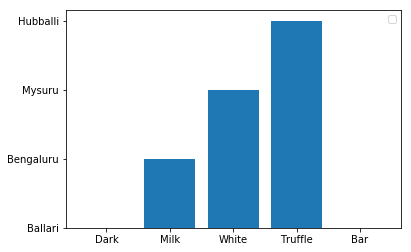

In [46]:
import matplotlib.pyplot as plt
plt.legend()

x=data['Product']
y=data['Location']
plt.bar(x,y)
plt.show()

In [73]:
original = pd.read_excel("C:/Users/hp5cd/OneDrive/Desktop/chocolate_sales.xlsx")

print("\nBest Products:")
print(original.groupby('Product')['Units_Sold'].mean())

print("\nBest Locations:")
print(original.groupby('Location')['Units_Sold'].mean())

print("\nPrice vs Sales:")
print(original[['Price','Units_Sold']].corr())


Best Products:
Product
Bar        200.000000
Dark       143.333333
Milk       146.666667
Truffle     70.000000
White      100.000000
Name: Units_Sold, dtype: float64

Best Locations:
Location
Ballari      122.5
Bengaluru    150.0
Hubballi     110.0
Mysuru       140.0
Name: Units_Sold, dtype: float64

Price vs Sales:
               Price  Units_Sold
Price       1.000000   -0.853729
Units_Sold -0.853729    1.000000


SALES REPORT

Total Units Sold: 1980
Total Revenue: 83200

Sales by Product:
Product
0    600
1    430
2    440
3    210
4    300
Name: Units_Sold, dtype: int64

Sales by Location:
Location
0    490
1    600
2    330
3    560
Name: Units_Sold, dtype: int64


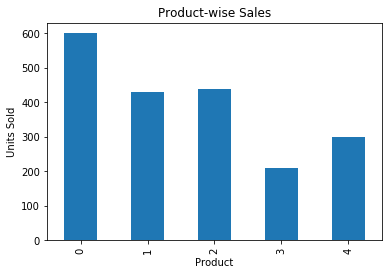

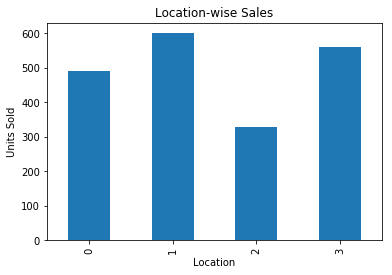


BUSINESS INSIGHTS

Best Selling Product: Bar
Best Performing Location: 1

SUGGESTIONS
- Increase production of high-demand products
- Focus marketing in high-performing locations
- Adjust pricing strategies to improve sales


In [86]:
print("SALES REPORT")

total_sales = data['Units_Sold'].sum()
total_revenue = data['Revenue'].sum()

print("\nTotal Units Sold:", total_sales)
print("Total Revenue:", total_revenue)

print("\nSales by Product:")
print(data.groupby('Product')['Units_Sold'].sum())

print("\nSales by Location:")
print(data.groupby('Location')['Units_Sold'].sum())


import matplotlib.pyplot as plt

data.groupby('Product')['Units_Sold'].sum().plot(kind='bar')
plt.title("Product-wise Sales")
plt.xlabel("Product")
plt.ylabel("Units Sold")
plt.show()

data.groupby('Location')['Units_Sold'].sum().plot(kind='bar')
plt.title("Location-wise Sales")
plt.xlabel("Location")
plt.ylabel("Units Sold")
plt.show()



print("\nBUSINESS INSIGHTS")

best_product = original.groupby('Product')['Units_Sold'].sum().idxmax()
print("\nBest Selling Product:", best_product)

best_location = data.groupby('Location')['Units_Sold'].sum().idxmax()
print("Best Performing Location:", best_location)


print("\nSUGGESTIONS")

print("- Increase production of high-demand products")
print("- Focus marketing in high-performing locations")
print("- Adjust pricing strategies to improve sales")


Predicted Sales: [204.28906926 142.30926138 141.84640434]
Mean Squared Error: 274.28078180723514


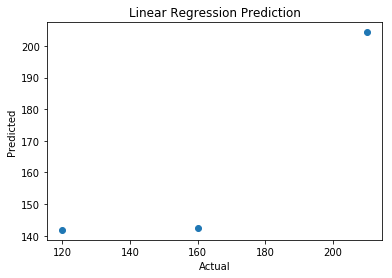


Best Product:
Product
Bar        200.000000
Dark       143.333333
Milk       146.666667
Truffle     70.000000
White      100.000000
Name: Units_Sold, dtype: float64

Best Location:
Location
Ballari      122.5
Bengaluru    150.0
Hubballi     110.0
Mysuru       140.0
Name: Units_Sold, dtype: float64


In [85]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

original = pd.read_excel("C:/Users/hp5cd/OneDrive/Desktop/chocolate_sales.xlsx")

data = original.copy()

data = data.drop('Date', axis=1)

data['Product'] = data['Product'].astype('category').cat.codes
data['Location'] = data['Location'].astype('category').cat.codes

X = data[['Product', 'Location', 'Price']]
y = data['Units_Sold']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("\nPredicted Sales:", y_pred)

mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Linear Regression Prediction")
plt.show()


print("\nBest Product:")
print(original.groupby('Product')['Units_Sold'].mean())

print("\nBest Location:")
print(original.groupby('Location')['Units_Sold'].mean())
